Saving ngc2420_gaia.csv to ngc2420_gaia (1).csv
Final cluster members: 368


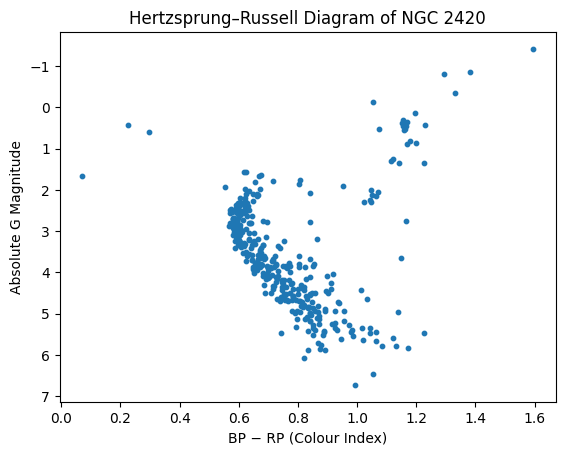

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# -----------------------------
# 1. Load Gaia CSV file

# Upload file
uploaded = files.upload()

# Get filename
filename = list(uploaded.keys())[0]

# Load CSV
df = pd.read_csv(filename)

# -----------------------------
# 2. Apply filtering conditions
# -----------------------------

df = df.dropna(subset=[
    "parallax",
    "parallax_error",
    "phot_g_mean_mag",
    "bp_rp"
])

df = df[
    (df["parallax"] > 0) &
    (df["parallax_error"] < 0.2) &
    ((df["parallax"] / df["parallax_error"]) > 5) &
    (df["parallax"] >= 0.3) &
    (df["parallax"] <= 0.6)
]

print("Final cluster members:", len(df))

# -----------------------------
# 3. Compute Absolute Magnitude
# -----------------------------

# Distance and absolute magnitude
df["distance_pc"] = 1000 / df["parallax"]
df["abs_g_mag"] = df["phot_g_mean_mag"] + 5 - 5 * np.log10(df["distance_pc"])

# HR Diagram
plt.figure()
plt.scatter(df["bp_rp"], df["abs_g_mag"], s=10)
plt.gca().invert_yaxis()  # Bright stars at top
plt.xlabel("BP − RP (Colour Index)")
plt.ylabel("Absolute G Magnitude")
plt.title("Hertzsprung–Russell Diagram of NGC 2420")
plt.show()
